In [1]:
import scipy.optimize as so
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Define plotting assistants 
# List of default colors
color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Plot parameters and sizes
plt.rc('font', size = 16)
plt.rc('axes', linewidth=1, titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)    # fontsize of the x and y labels
plt.rc('xtick', top=True, bottom=True, direction='in')
plt.rc('ytick', left=True, right=True, direction='in') 
plt.rc('figure', titlesize=5)
plt.rc('legend', fontsize=14)
plt.rc('lines', linewidth=2)

In [3]:
# Read in the simulation data
data = pd.read_csv("Simulation Results/tj.dat", sep=r'\s+')

[]

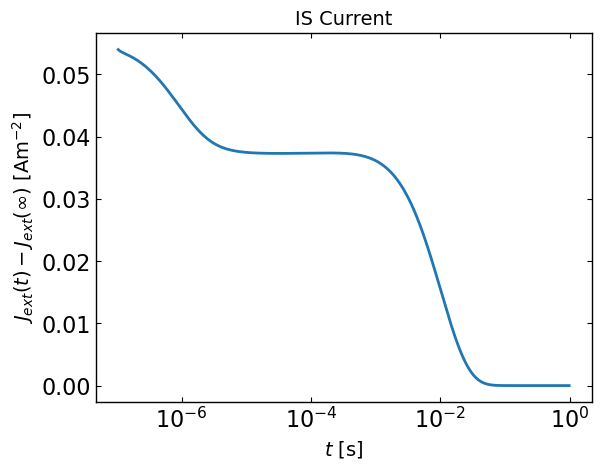

In [4]:
# Reduce the window of current and time to be used for fitting
start_index = 57
end_index = 849

time = data['t'].iloc[start_index:end_index].values
current_density = (data['Jext'].iloc[start_index:end_index].values - data['Jext'].iloc[-1])

plt.plot(time, current_density)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)-J_{ext}(\\infty)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("IS Current")
plt.plot()

In [5]:
# Define the model function U 
def U_i(t, U_i, tau_i):
    return U_i*np.exp(-t/tau_i)

# Define a function that can calculate U(t) using any number of exponential curves
def U_N(t, U_values, tau_values, offset=0):
    # Make sure input is a numpy array 
    U_values = np.array(U_values)
    tau_values = np.array(tau_values)
    
    # Make sure time is correct here
    if not isinstance(t, list) and not isinstance(t, np.ndarray):
        t = np.array([t])
    elif not isinstance(t, np.ndarray):
        t = np.array(t)
    
    return (U_values @ np.exp(-np.outer(1/tau_values, t))) + offset

def U_fit(t, J, tau0):
    # Make sure array-like objects are numpy arrays
    t = np.array(t)
    J = np.array(J)
    tau0 = np.array(tau0)
    
    # Create initial guess for U 
    M = len(tau0)
    U0 = np.zeros(M)
    
    # Create an initial array-like guess of variables
    x0 = np.concatenate((U0, tau0, np.array([0])))
    
    # Assume an array of dimension M + M + 1, where the first M values 
    # correspond to U values, the second group of M values to the tau values 
    # and the final value to the offset
    error = lambda x : ((x[:M] @ np.exp(-np.outer(1/x[M:-1], t))) + x[-1]) - J
    
    # Fit the params. Note, setting x_scale='jac' is crucial for accurate fits
    fit = so.least_squares(error, x0=x0, x_scale='jac')
 
    return fit
    

[]

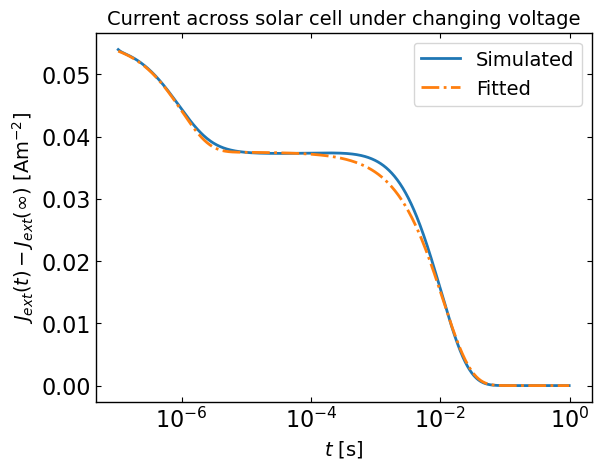

In [6]:
# Manually try fitting two curves and check U_N works
start_index = 57
end_index = 849

time = data['t'].iloc[start_index:end_index].values
current_density = (data['Jext'].iloc[start_index:end_index].values - data['Jext'].iloc[-1])
fitted_current_density = U_N(time, [0.018,0.0375], [1E-6, 1.1E-2], offset=0)

plt.plot(time, current_density, label='Simulated')
plt.plot(time, fitted_current_density, label='Fitted', linestyle='-.')
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)-J_{ext}(\\infty)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("Current across solar cell under changing voltage")
plt.legend()
plt.plot()

In [7]:
# Now try running automated fitting for two curves
fit_results = U_fit(time, current_density, np.geomspace(time[0], time[-1], 2))

[]

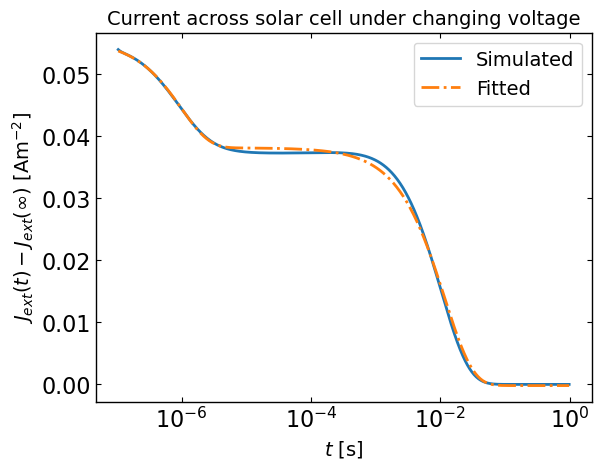

In [8]:
# Check the fitted results make sense 
M = int((len(fit_results.x)-1)/2)
U_values_fit = fit_results.x[:M]
tau_values_fit = fit_results.x[M:-1]
offset = fit_results.x[-1]

time = data['t'].iloc[start_index:end_index].values
current_density = (data['Jext'].iloc[start_index:end_index].values - data['Jext'].iloc[-1])
fitted_current_density = U_N(time, U_values_fit, tau_values_fit, offset=offset)

plt.plot(time, current_density, label='Simulated')
plt.plot(time, fitted_current_density, label='Fitted', linestyle='-.')
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)-J_{ext}(\\infty)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("Current across solar cell under changing voltage")
plt.legend()
plt.plot()


In [9]:
fit_results.x

array([ 1.73483590e-02,  3.83254508e-02,  9.86654821e-07,  1.17066549e-02,
       -1.90931080e-04])

In [10]:
len(fit_results.x)

5

In [11]:
# Now we can try itterating through different numbers of curves to see which returns the best fit 
def multi_U_fit(t, J, max_iter=10):
    # Define a counter variable
    i = 1
    
    # Define an array to store fits
    fits = []
    
    # Previous err 
    last_err = np.inf
    
    while i <= 10:
        # Generate initial guess of t0 params
        tau0 = np.geomspace(t[0], t[-1], i)
        
        # Run the fit function 
        fit_results = U_fit(t, J, tau0)
        
        # Check to see whether the change in error is below the threshold
        fits.append(fit_results)
        
        i += 1
        
    return fits

In [12]:
fits = multi_U_fit(time, current_density)

/tmp/ipykernel_7397/800236895.py:35: RuntimeWarning: overflow encountered in exp
  error = lambda x : ((x[:M] @ np.exp(-np.outer(1/x[M:-1], t))) + x[-1]) - J
/tmp/ipykernel_7397/800236895.py:35: RuntimeWarning: invalid value encountered in matmul
  error = lambda x : ((x[:M] @ np.exp(-np.outer(1/x[M:-1], t))) + x[-1]) - J


[]

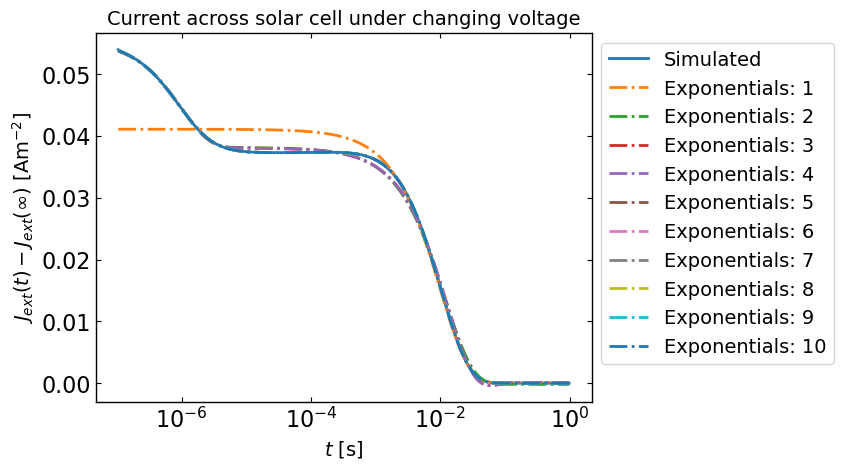

In [13]:
# Manually try fitting two curves and check U_N works
start_index = 57
end_index = 849

time = data['t'].iloc[start_index:end_index].values
current_density = (data['Jext'].iloc[start_index:end_index].values - data['Jext'].iloc[-1])
fitted_current_density = U_N(time, [0.018,0.0375], [1E-6, 1.1E-2], offset=0)

plt.plot(time, current_density, label='Simulated')
i = 1
for fit in fits[:]:
    M = int((len(fit.x)-1)/2)
    fitted_current_density = U_N(time, fit.x[:M], fit.x[M:-1], offset=fit.x[-1])
    plt.plot(time, fitted_current_density, label=f"Exponentials: {i}", linestyle='-.')
    i += 1
    
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)-J_{ext}(\\infty)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("Current across solar cell under changing voltage")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.plot()

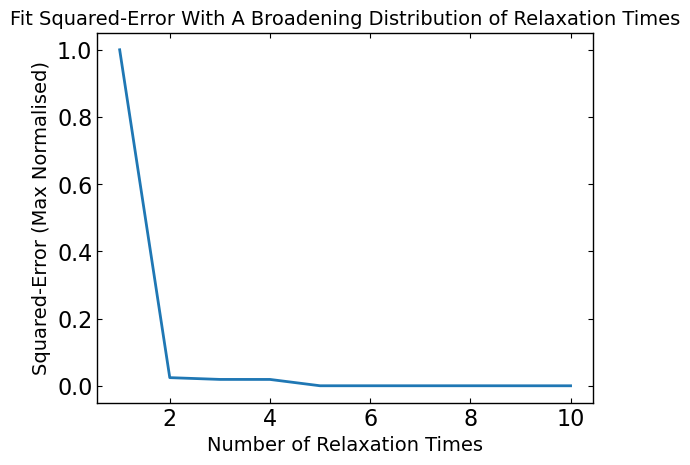

In [14]:
# Plot how the cost function changes with exponential number 
costs = np.array([])

for fit in fits:
    costs = np.append(costs, fit.cost)

plt.plot(range(1, len(costs)+1), costs/costs.max())
plt.xlabel("Number of Relaxation Times")
plt.ylabel("Squared-Error (Max Normalised)")
plt.title("Fit Squared-Error With A Broadening Distribution of Relaxation Times")
plt.show()

In [15]:
print(costs/costs.max())

[1.00000000e+00 2.42378247e-02 1.89520030e-02 1.88914181e-02
 6.42822995e-05 7.59915699e-05 5.38998112e-05 7.43918781e-05
 1.31171554e-05 5.59573279e-06]


## Linear Methods
As well as trying the non-linear approach, I've re-implemented the linear methodology to see if that offers any improvement

In [16]:
# Define linear fit
def U_linear_fit(t, J, tau):
    # Make sure array-like objects are numpy arrays
    t = np.array(t)
    J = np.array(J)
    tau = np.array(tau)

    # Create initial guess for U 
    M = len(tau)
    U0 = np.zeros(M)

    # Create an initial array-like guess of variables
    x0 = np.concatenate((U0, np.array([0])))

    # Assume an array of dimension M + M + 1, where the first M values 
    # correspond to U values, the second group of M values to the tau values 
    # and the final value to the offset
    error = lambda x : ((x[:-1] @ np.exp(-np.outer(1/tau, t))) + x[-1]) - J

    fit = so.least_squares(error, x0=x0)

    # Assume params is of dimension 2 x m, where m is the number of tau/U_values
    return fit

In [17]:
#. Trying the improved linear fit function 
tau_linear_fit = np.geomspace(time[0], time[-1], 20)
linear_fit_params = U_linear_fit(time, current_density, tau_linear_fit)

[]

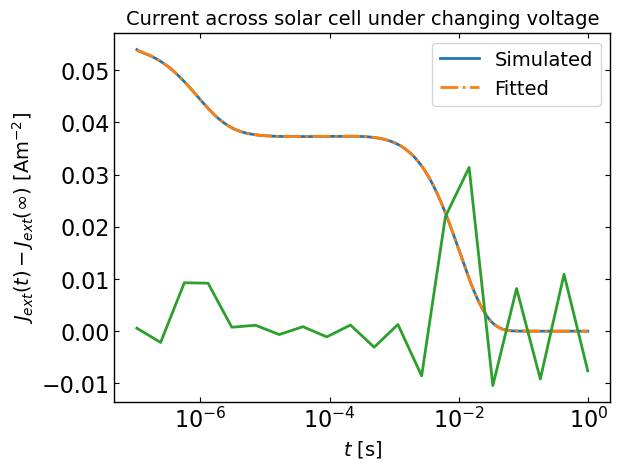

In [18]:
# Plot the linear fit 
M = int((len(linear_fit_params.x)-1)/2)
U_values_linear_fit = linear_fit_params.x[:-1]
offset = linear_fit_params.x[-1]

fitted_current_density = U_N(time, U_values_linear_fit, tau_linear_fit, offset=offset)

plt.plot(time, current_density, label='Simulated')
plt.plot(time, fitted_current_density, label='Fitted', linestyle='-.')
plt.plot(tau_linear_fit, U_values_linear_fit)

plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)-J_{ext}(\\infty)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("Current across solar cell under changing voltage")
plt.legend()
plt.plot()

I get the same issues as before